In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)


from environment.my_gridworld import EnhancedGridWorldEnv
from model.dqn_lstm import LSTMDQNAgent
import random
import numpy as np

In [ ]:
import torch
import matplotlib.pyplot as plt

import torch.nn as nn
from collections import deque



def train_lstm_dqn_agent(
    env,
    num_episodes=400,
    save_best_model_path=None,
    save_last_model_path=None,
    save_plot_path=None,
    agent_hyperparams=None,
    seed=42
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    defaults = {
        'lstm_hidden_size': 32,
        'lstm_num_layers': 1,
        'learning_rate': 3e-5,
        'gamma': 0.98,
        'epsilon_start': 1.0,
        'epsilon_end': 0.01,
        'epsilon_decay': 3000,
        'memory_capacity': 8000,
        'batch_size': 32,
        'tau': 0.001,
        'sequence_length': 10
    }

    if agent_hyperparams:
        defaults.update(agent_hyperparams)

    agent = LSTMDQNAgent(
        env=env,
        lstm_hidden_size=defaults['lstm_hidden_size'],
        lstm_num_layers=defaults['lstm_num_layers'],
        learning_rate=defaults['learning_rate'],
        gamma=defaults['gamma'],
        epsilon_start=defaults['epsilon_start'],
        epsilon_end=defaults['epsilon_end'],
        epsilon_decay=defaults['epsilon_decay'],
        memory_capacity=defaults['memory_capacity'],
        batch_size=defaults['batch_size'],
        tau=defaults['tau'],
        sequence_length=defaults['sequence_length']
    )

    best_avg_reward = -float('inf')

    for episode in range(num_episodes):
        reward, length, loss = agent.train_episode(episode)

        window = min(30, len(agent.episode_rewards))
        avg_reward = np.mean(agent.episode_rewards[-window:]) if window > 0 else reward

        if save_best_model_path and avg_reward > best_avg_reward:
            best_avg_reward = avg_reward
        

        if episode % 50 == 0 or episode == num_episodes - 1:
            epsilon = agent.epsilon_values[-1] if agent.epsilon_values else 1.0
            print(f"Episode {episode:4d}/{num_episodes} | "
                  f"Reward: {reward:6.2f} (avg: {avg_reward:6.2f}) | "
                  f"Length: {length:3d} | "
                  f"Loss: {loss:7.4f} | "
                  f"Epsilon: {epsilon:.3f} | "
                  f"Best avg: {best_avg_reward:6.2f}")

            if avg_reward > 0.95:
                print(f"Early stopping: success achieved in {env.env_id}!")
                break

    if save_last_model_path:
        try:
            torch.save(agent.policy_net.state_dict(), save_last_model_path)
        except:
            pass

    if save_plot_path:
        agent.plot_training_history(save_path=save_plot_path)

    print(f"\nFinal evaluation for {env.env_id}:")
    eval_results = agent.evaluate(n_episodes=20, render=False)
    print(f"Mean reward: {eval_results['mean_reward']:.2f} ± {eval_results['std_reward']:.2f}")
    print(f"Success rate: {eval_results['success_rate']:.2%}")

    agent.evaluate(n_episodes=1, render=False, max_steps=50)

    return agent


os.makedirs("results/weights", exist_ok=True)

colors = np.arange(25).reshape(5, 5)
env1 = EnhancedGridWorldEnv(
    height=5, width=5, colors=colors, n_colors=25,
    pos_goal=(4, 4), pos_agent=(0, 0),max_steps=100, use_penalties=True, env_id="Env1"
)
env1.reset()
env1.close()

env2 = EnhancedGridWorldEnv(
    height=5, width=5, n_colors=5,
    pos_goal=(4, 4), pos_agent=(0, 0), max_steps=100, use_penalties=True, env_id="Env2", seed=42
)
env2.reset()
env2.close()


agent_configs = [
    {
        "env": env1,
        "num_episodes": 100,
        "hyperparams": {
            "lstm_hidden_size": 8,
            "lstm_num_layers": 1,
            "learning_rate": 1e-3,
            "gamma": 0.95,
            "epsilon_decay": 1000,
            "memory_capacity": 10000,
            "batch_size": 8,
            "tau": 0.001,
        },
        "seed": 101
    },
    {
        "env": env2,
        "num_episodes": 100,
        "hyperparams": {
            "lstm_hidden_size": 16,
            "lstm_num_layers": 1,
            "learning_rate": 1e-4,
            "gamma": 0.95,
            "epsilon_decay": 800,
            "memory_capacity": 5000,
            "batch_size":16,
            "tau": 0.001,
            "sequence_length": 3,
        },
        "seed": 102
    },
      
]

agents = []
for i, config in enumerate(agent_configs, 1):
    env = config["env"]
    env_id = env.env_id
    print(f" Training Agent {i} for {env_id}")

    agent = train_lstm_dqn_agent(
        env=env,
        num_episodes=config["num_episodes"],
        save_best_model_path=f"results/weights/best_{env_id}.pth",
        save_plot_path=f"results/training_{env_id}.png",
        agent_hyperparams=config["hyperparams"],
        seed=config["seed"]
    )
    agents.append(agent)

print("   - Best model weights:   results/weights/best_*.pth")
print("   - Training plots:       results/training_*.png")

 Training Agent 1 for Env1
Using device: cuda
Episode    0/100 | Reward:  -3.76 (avg:  -3.76) | Length:  83 | Loss:  0.0103 | Epsilon: 0.921 | Best avg:  -3.76


### Тут не получилось нормально обучить, еще смущает лос на предыдущем графике

 Training Agent 1 for Env3
Using device: cuda
Episode    0/150 | Reward:   0.00 (avg:   0.00) | Length: 300 | Loss:  0.0056 | Epsilon: 0.862 | Best avg:   0.00
Episode   50/150 | Reward:   1.00 (avg:   0.57) | Length: 187 | Loss:  0.0008 | Epsilon: 0.014 | Best avg:   0.57
Episode  100/150 | Reward:   0.00 (avg:   0.00) | Length: 300 | Loss:  0.0005 | Epsilon: 0.010 | Best avg:   0.60
Episode  149/150 | Reward:   0.00 (avg:   0.00) | Length: 300 | Loss:  0.0002 | Epsilon: 0.010 | Best avg:   0.60
Training history saved to results/training_Env3.png

Final evaluation for Env3:
Mean reward: 0.00 ± 0.00
Success rate: 0.00%
 Training Agent 2 for Env4
Using device: cuda
Episode    0/200 | Reward: -20.25 (avg: -20.25) | Length: 300 | Loss:  0.0103 | Epsilon: 0.862 | Best avg: -20.25


KeyboardInterrupt: 

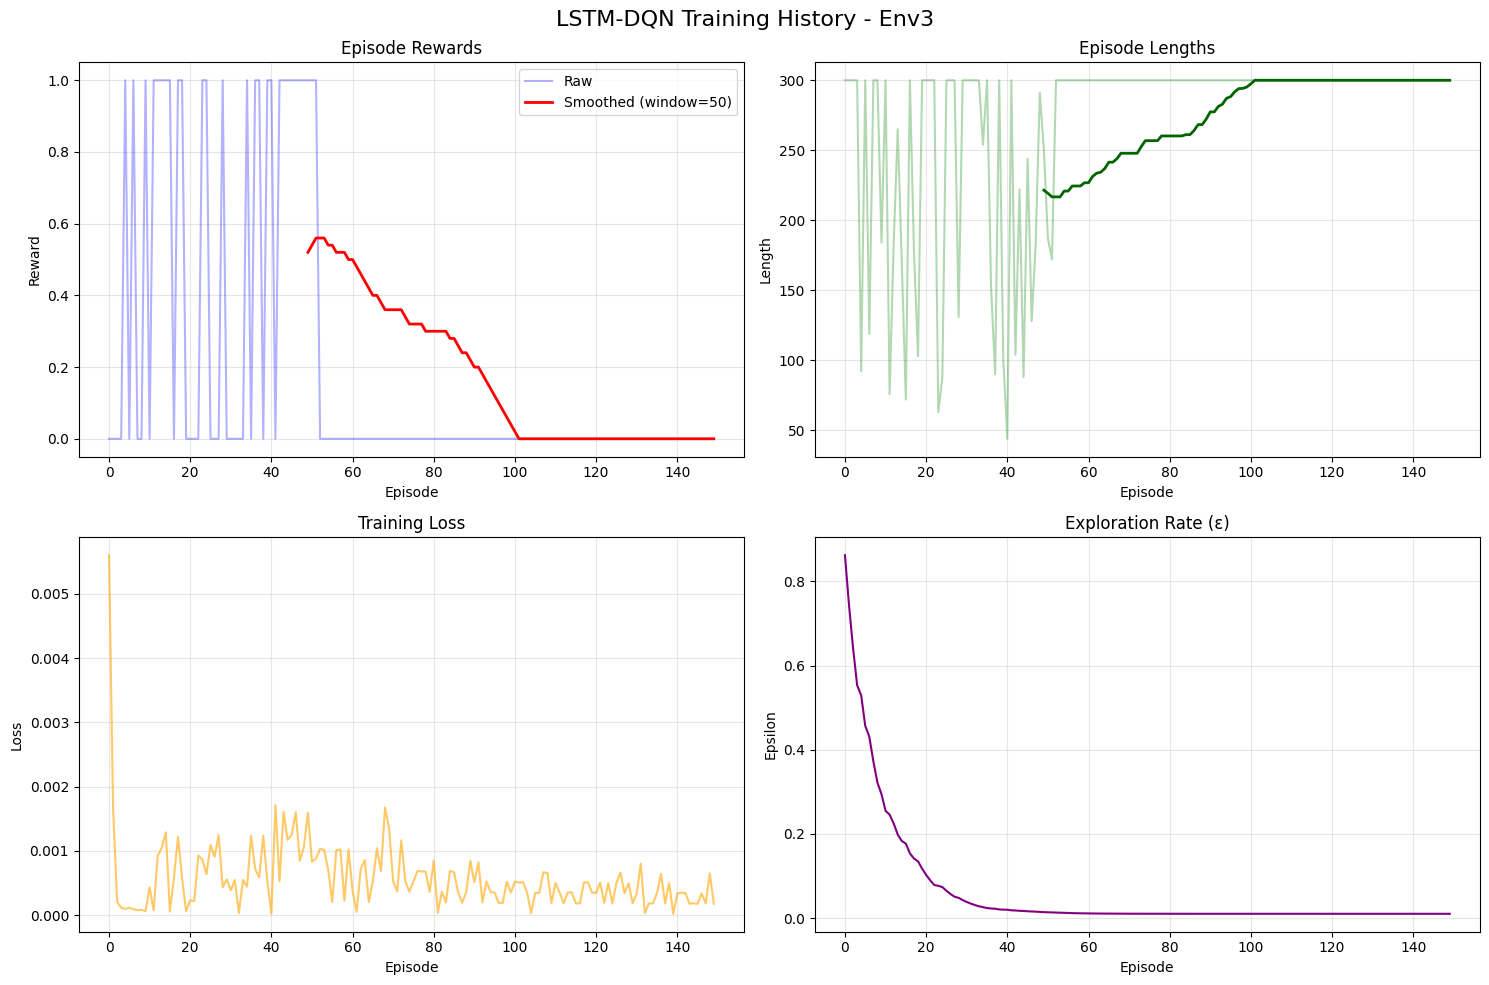

In [51]:

os.makedirs("results", exist_ok=True)
os.makedirs("results", exist_ok=True)

np.random.seed(42)
obs_mask3 = np.random.rand(10, 10) < 0.10
obs_mask3[0, 0] = obs_mask3[9, 9] = False
env3 = EnhancedGridWorldEnv(
    height=10, width=10, n_colors=7, obstacle_mask=obs_mask3,
    pos_goal=(9, 9), pos_agent=(0, 0), max_steps=300, env_id="Env3", seed=42
)
env3.reset()
env3.close()
    
np.random.seed(43)
obs_mask4 = np.random.rand(10, 10) < 0.10
obs_mask4[0, 0] = obs_mask4[9, 9] = False
env4 = EnhancedGridWorldEnv(
    height=10, width=10, n_colors=4, obstacle_mask=obs_mask4,
    pos_goal=(9, 9), pos_agent=(0, 0),  max_steps=300, use_penalties=True, env_id="Env4", seed=42
)
env4.reset()
env4.close()


agent_configs = [
    {
        "env": env3,
        "num_episodes": 150,
        "hyperparams": {
            "lstm_hidden_size": 32,
            "lstm_num_layers": 1,
            "learning_rate": 1e-4,
            "gamma": 0.99,
            "epsilon_decay": 2000,
            "memory_capacity": 15000,
            "tau": 0.001,
            "batch_size": 32,
        },
        "seed": 103
    },
    {
        "env": env4,
        "num_episodes": 200,
        "hyperparams": {
            "lstm_hidden_size": 32,
            "lstm_num_layers": 1,
            "learning_rate": 1e-4,
            "gamma": 0.99,
            "epsilon_decay": 2000,
            "memory_capacity": 15000,
            "tau": 0.001,
            "batch_size": 32,
            "sequence_length": 6,
        },
        "seed": 104
    }
]

agents = []
for i, config in enumerate(agent_configs, 1):
    env = config["env"]
    env_id = env.env_id
    print(f" Training Agent {i} for {env_id}")

    agent = train_lstm_dqn_agent(
        env=env,
        num_episodes=config["num_episodes"],
        save_best_model_path=f"results/weights/best_{env_id}.pth",
        save_plot_path=f"results/training_{env_id}.png",
        agent_hyperparams=config["hyperparams"],
        seed=config["seed"]
    )
    agents.append(agent)

print("   - Best model weights:   results/weights/best_*.pth")
print("   - Training plots:       results/training_*.png")